## 위클리 챌린지 1. 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요. (산점도 시각화 추가)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification      # 가상 분류 데이터 생성
from sklearn.model_selection import train_test_split   # 데이터 분할 함수
from sklearn.neighbors import KNeighborsClassifier      # K-NN 모델
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# make_classification: 분류용 가상 데이터를 자동으로 만들어주는 함수
# 두 개의 특성(Feature)으로 구성된 이진 분류 데이터셋
X, y = make_classification(
    n_samples=1000,     # 데이터 샘플 수 (행 개수)
    n_features=2,       # 특성 수 → 2개여야 2D 그래프로 시각화 가능
    n_informative=2,    # 실제로 분류에 유용한 특성 수
    n_redundant=0,      # 중복 특성 수 (불필요한 특성 없음)
    n_classes=2,        # 클래스 수: 0 또는 1 (이진 분류)
    random_state=42     # 랜덤 시드 고정 → 실행할 때마다 같은 결과
)

print(f'전체 데이터: X={X.shape}, y={y.shape}')
print(f'클래스 0: {(y==0).sum()}개, 클래스 1: {(y==1).sum()}개')

전체 데이터: X=(1000, 2), y=(1000,)
클래스 0: 498개, 클래스 1: 502개


In [ ]:
# ── 1차 분할: 전체에서 Train(60%) / 나머지(40%) 분리 ──
# test_size=0.4 → 40%를 나머지로 떼어냄
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# ── 2차 분할: 나머지(40%)를 Validation(20%) / Test(20%)로 분리 ──
# test_size=0.5 → 나머지의 50% = 전체의 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('=== 데이터셋 분할 결과 ===')
print(f'Train      : {len(X_train)}개 ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation : {len(X_val)}개 ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test       : {len(X_test)}개 ({len(X_test)/len(X)*100:.0f}%)')

=== 데이터셋 분할 결과 ===
Train      : 600개 (60%)
Validation : 200개 (20%)
Test       : 200개 (20%)


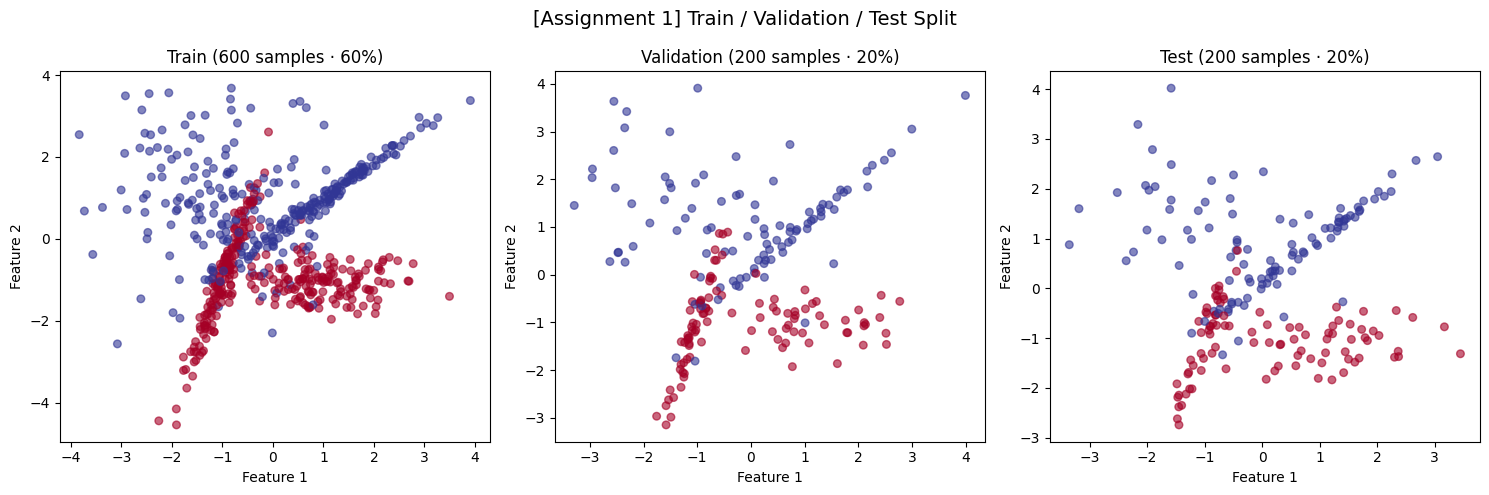

In [ ]:
# 각 분할 데이터를 산점도로 시각화
# x축 = Feature 1, y축 = Feature 2
# 파란 점 = Class 0, 빨간 점 = Class 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (X_train, y_train, 'Train (600 samples · 60%)'),
    (X_val,   y_val,   'Validation (200 samples · 20%)'),
    (X_test,  y_test,  'Test (200 samples · 20%)'),
]

for ax, (X_d, y_d, title) in zip(axes, datasets):
    ax.scatter(X_d[:,0], X_d[:,1], c=y_d, cmap='RdYlBu', alpha=0.6, s=30)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('[Assignment 1] Train / Validation / Test Split', fontsize=14)
plt.tight_layout()
plt.show()

## 위클리 챌린지 2. 가상 데이터셋을 생성하고(1번과제 데이터 활용), K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요.

In [ ]:
# K-NN 모델 생성 (K=5: 가장 가까운 5개 이웃 참고)
knn = KNeighborsClassifier(
    n_neighbors=5,          # K값: 이웃 몇 개를 볼지
    metric='euclidean'       # 거리 측정 방식: 유클리디안 거리
)

# Train 데이터로 학습 (fit = 학습하다)
knn.fit(X_train, y_train)

print(f'K-NN 학습 완료! (K=5)')
print(f'학습에 사용된 데이터: {len(X_train)}개')

K-NN 학습 완료! (K=5)
학습에 사용된 데이터: 600개


In [ ]:
# 테스트 데이터로 예측 (predict = 예측하다)
y_pred = knn.predict(X_test)

# 정확도 = 맞힌 개수 / 전체 개수
acc = accuracy_score(y_test, y_pred)

print('=== K-NN 예측 결과 (K=5) ===')
print(f'테스트 샘플 수: {len(y_test)}개')
print(f'정확도: {acc:.4f} ({acc*100:.2f}%)')
print()
print('=== 상세 분류 리포트 ===')
# precision: 예측한 것 중 맞은 비율
# recall: 실제 양성 중 맞게 예측한 비율
# f1-score: precision과 recall의 조화평균
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

=== K-NN 예측 결과 (K=5) ===
테스트 샘플 수: 200개
정확도: 0.9150 (91.50%)

=== 상세 분류 리포트 ===
              precision    recall  f1-score   support

     Class 0       0.87      0.97      0.92        95
     Class 1       0.97      0.87      0.91       105

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



Best K: 3  (Validation Accuracy: 94.00%)


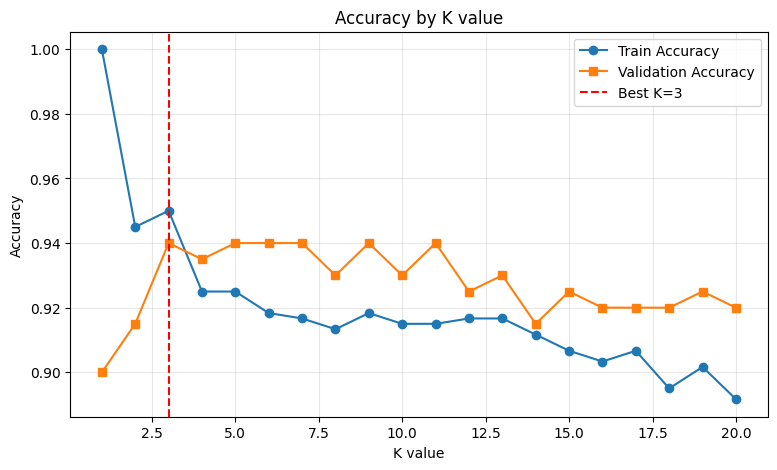

In [ ]:
# K값을 1~20까지 바꿔가며 Train, Validation 정확도 비교
# → 최적 K를 Validation 기준으로 선택 (Test는 마지막까지 안 봄!)
k_range = range(1, 21)
train_accs, val_accs = [], []

for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    val_accs.append(accuracy_score(y_val,   m.predict(X_val)))

best_k = list(k_range)[np.argmax(val_accs)]
print(f'Best K: {best_k}  (Validation Accuracy: {max(val_accs)*100:.2f}%)')

# 시각화
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, train_accs, 'o-', label='Train Accuracy')
ax.plot(k_range, val_accs,   's-', label='Validation Accuracy')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax.set_xlabel('K value'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.title('Accuracy by K value')
plt.show()



## 3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.

## Perceptron

In [ ]:
from sklearn.linear_model import Perceptron      # sklearn에서 퍼셉트론 모델을 가져옴
from sklearn.preprocessing import StandardScaler # 데이터 정규화 도구 (특성 범위를 통일시켜줌)
from sklearn.metrics import accuracy_score        # 정확도 계산 함수 (맞힌 개수 / 전체 개수)
from sklearn.metrics import classification_report  # precision, recall, f1-score 한번에 출력
from sklearn.metrics import confusion_matrix       # 실제 vs 예측 결과를 표로 정리

In [ ]:
scaler = StandardScaler()           # 정규화 도구 생성 (아직 계산은 안 함)

X_train_s = scaler.fit_transform(X_train)  # Train 데이터로 평균/표준편차 계산 후 바로 변환
                                            # fit: 평균/표준편차 계산 / transform: 실제 변환

X_val_s = scaler.transform(X_val)          # Val은 transform만 → Train 기준값 그대로 적용
                                            # fit을 다시 하면 Val 기준으로 새로 계산돼서
                                            # Train과 기준이 달라져 모델이 엉뚱한 값을 보게 됨

X_test_s = scaler.transform(X_test)        # Test도 transform만 → 같은 이유로 fit 금지

print("정규화 전  Train 평균 :", X_train.mean(axis=0).round(3))   # 정규화 전 평균 확인
print("정규화 후  Train 평균 :", X_train_s.mean(axis=0).round(3))  # 정규화 후 평균 → 0에 가까워야 정상
print("정규화 후  Train 표준편차:", X_train_s.std(axis=0).round(3)) # 정규화 후 표준편차 → 1이어야 정상

정규화 전  Train 평균 : [-0.06  -0.041]
정규화 후  Train 평균 : [-0.  0.]
정규화 후  Train 표준편차: [1. 1.]


In [ ]:
perceptron = Perceptron(             # 퍼셉트론 모델 객체 생성
    max_iter=1000,               # 최대 반복 횟수 → 600개 전체를 한 바퀴 도는 게 1번
                                    # 오답이 없어지면 그 전에 멈추고, 아니면 1000번에서 강제 종료
    eta0=0.1,                    # 학습률 → 오답 시 가중치를 얼마나 크게 수정할지
                                    # 크면(0.9) 빠르지만 불안정 / 작으면(0.001) 느리지만 안정적
    random_state=42               # 초기 가중치를 랜덤으로 설정하는데 그 시드 고정
                                    # → 실행할 때마다 같은 결과가 나오게 함
)

perceptron.fit(X_train_s, y_train)  # 학습 시작 (Train 데이터만 사용)
                                    # 내부 동작:
                                    # ① 샘플 하나 입력 (Feature1, Feature2)
                                    # ② z = w1·x1 + w2·x2 + b 계산
                                    # ③ 계단함수: z > 0이면 1, z ≤ 0이면 0 출력
                                    # ④ 정답과 비교 → 틀리면 w ← w + η·y·x 로 수정
                                    # ⑤ 600개 전부 돌면 1번 반복 완료 → 반복

print(f"학습 완료!")
print(f"실제 반복 횟수: {perceptron.n_iter_}번")          # max_iter 전에 수렴했으면 더 적게 나옴
print(f"학습된 가중치: {perceptron.coef_[0].round(3)}")    # Feature1, Feature2 각각의 최종 가중치
print(f"편향 (b)     : {perceptron.intercept_[0]:.3f}")    # 결정 경계 위치 조절값

학습 완료!
실제 반복 횟수: 7번
학습된 가중치: [-0.08   0.129]
편향 (b)     : 0.100


In [ ]:
y_pred_train = perceptron.predict(X_train_s)  # Train 데이터로 예측 (학습에 쓴 데이터)
y_pred_val   = perceptron.predict(X_val_s)    # Validation 데이터로 예측 (중간 점검용)
y_pred_test  = perceptron.predict(X_test_s)   # Test 데이터로 예측 (최종 성적 확인용)
                                               # predict 내부: z = w·x + b → 계단함수 → 0 또는 1

train_acc = accuracy_score(y_train, y_pred_train)  # Train 정확도 계산
val_acc   = accuracy_score(y_val,   y_pred_val)    # Validation 정확도 계산
test_acc  = accuracy_score(y_test,  y_pred_test)   # Test 정확도 계산
                                                    # 세 값이 비슷하면 과적합 없음
                                                    # Train만 높고 Val/Test가 낮으면 과적합

print("=== 퍼셉트론 정확도 ===")
print(f"Train      : {train_acc:.4f} ({train_acc*100:.2f}%)")  # 학습 데이터 정확도
print(f"Validation : {val_acc:.4f}   ({val_acc*100:.2f}%)")    # 검증 데이터 정확도
print(f"Test       : {test_acc:.4f}   ({test_acc*100:.2f}%)")   # 최종 테스트 정확도
print()
print("=== 상세 분류 리포트 (Test 기준) ===")
print(classification_report(y_test, y_pred_test,           # 실제값 vs 예측값 비교
                             target_names=['Class 0', 'Class 1']))  # 클래스 이름 지정
                                                            # precision: 1로 예측한 것 중 실제로 1인 비율
                                                            # recall   : 실제 1인 것 중 1로 맞게 예측한 비율
                                                            # f1-score : precision과 recall의 조화평균

=== 퍼셉트론 정확도 ===
Train      : 0.7417 (74.17%)
Validation : 0.7150   (71.50%)
Test       : 0.7900   (79.00%)

=== 상세 분류 리포트 (Test 기준) ===
              precision    recall  f1-score   support

     Class 0       0.98      0.57      0.72        95
     Class 1       0.72      0.99      0.83       105

    accuracy                           0.79       200
   macro avg       0.85      0.78      0.78       200
weighted avg       0.84      0.79      0.78       200



In [ ]:
cm = confusion_matrix(y_test, y_pred_test)  # 실제값 vs 예측값을 2x2 표로 만듦
                                             # 행 = 실제 클래스 / 열 = 예측 클래스

print("=== 혼동 행렬 ===")
print(f"            pred:0  pred:1")
print(f"  true:0      {cm[0,0]:3d}     {cm[0,1]:3d}")  # cm[0,0]=TN(맞음) / cm[0,1]=FP(틀림)
print(f"  true:1      {cm[1,0]:3d}     {cm[1,1]:3d}")  # cm[1,0]=FN(틀림) / cm[1,1]=TP(맞음)
print()
print(f"✅ TN - Class 0 정확히 예측: {cm[0,0]}개")  # 실제 0 → 0으로 맞게 예측
print(f"✅ TP - Class 1 정확히 예측: {cm[1,1]}개")  # 실제 1 → 1로 맞게 예측
print(f"❌ FP - Class 0 → 1 오예측 : {cm[0,1]}개")  # 실제 0인데 1로 잘못 예측
print(f"❌ FN - Class 1 → 0 오예측 : {cm[1,0]}개")  # 실제 1인데 0으로 잘못 예측

=== 혼동 행렬 ===
            pred:0  pred:1
  true:0       54      41
  true:1        1     104

✅ TN - Class 0 정확히 예측: 54개
✅ TP - Class 1 정확히 예측: 104개
❌ FP - Class 0 → 1 오예측 : 41개
❌ FN - Class 1 → 0 오예측 : 1개


## SVM (Support Vector Machine)




In [ ]:
from sklearn.svm import SVC
# SVC = Support Vector Classifier
# sklearn에서 SVM 분류기를 제공하는 클래스이다
# SVM: 마진을 최대화하는 결정 경계(w, b)를 수학적으로 계산하는 알고리즘이다

from sklearn.metrics import accuracy_score, confusion_matrix
# accuracy_score: 예측값과 실제값을 비교해서 정확도를 계산한다
# confusion_matrix: 어떤 클래스를 어떻게 틀렸는지 2×2 표로 보여준다

In [ ]:
svm_model = SVC(
    kernel='rbf',
    # kernel: 데이터를 어떤 방식으로 분리할지 결정하는 함수이다
    # 'rbf': 데이터를 고차원으로 변환해서 비선형 경계를 찾을 수 있게 해준다
    #        우리 데이터는 직선 하나로 분리 안 되는 구조이므로 rbf를 선택한다
    #        (실제로 고차원으로 올리지 않고 수식으로만 계산 = 커널 트릭)

    C=1.0,
    # C: 오류를 얼마나 허용할지 결정하는 파라미터이다
    # C가 크면: 오류 최소화 → 경계가 복잡해짐 → 과적합 위험
    # C가 작으면: 오류 허용 → 마진 넓게 유지 → 과소적합 위험
    # C=1.0: 균형 잡힌 sklearn 기본값이다

    gamma='scale'
    # gamma: rbf 커널에서 각 데이터 포인트의 영향 범위를 결정한다
    # gamma가 크면: 가까운 점만 영향 → 경계가 구불구불 → 과적합 위험
    # gamma가 작으면: 멀리까지 영향 → 경계가 단순 → 과소적합 위험
    # 'scale': gamma = 1 / (특성 수 × X의 분산) 으로 자동 계산한다
    #          데이터 스케일에 맞게 자동 조정되므로 기본값으로 적합하다
    # random_state 없음: SVM은 수학적 최적화로 w를 계산하기 때문에
    #                    랜덤 요소가 없다 → random_state 자체가 불필요하다
)
# SVC 객체 생성 완료 → 아직 학습은 하지 않은 상태이다
# w(가중치), b(편향) 값이 아직 결정되지 않은 빈 모델이다

print("모델 생성 완료")
print(svm_model)
# 현재 설정된 하이퍼파라미터를 출력해서 확인한다

모델 생성 완료
SVC()


In [ ]:
svm_model.fit(X_train_s, y_train)
# fit(): 모델이 실제로 학습하는 단계이다
# 내부에서 일어나는 일:
#   1. X_train_s의 모든 점에서 결정 경계까지의 거리를 계산한다
#   2. 각 클래스에서 경계에 가장 가까운 점들(서포트 벡터)을 찾는다
#   3. 서포트 벡터 사이의 마진이 최대가 되는 w, b를 수학적으로 계산한다
# X_train_s를 쓰는 이유: SVM은 거리 기반 알고리즘이다
#   정규화 없이 학습하면 값이 큰 특성이 거리 계산을 지배해서 성능이 떨어진다
#   예) Feature1 범위가 0~1000, Feature2 범위가 0~1이면
#       Feature1의 거리가 압도적으로 커져서 Feature2는 무시된다

print(f"학습에 사용된 서포트 벡터 수: {svm_model.n_support_}")
# n_support_: 각 클래스별 서포트 벡터 개수를 보여준다
# [Class0 서포트벡터 수, Class1 서포트벡터 수] 형태로 출력된다
# 서포트 벡터가 많다 = 경계 근처에 점이 많다 = 분리가 어려운 데이터라는 의미이다

학습에 사용된 서포트 벡터 수: [102 106]


In [ ]:
y_train_pred_svm = svm_model.predict(X_train_s)
# predict(): 학습된 w, b로 각 점이 어느 클래스인지 예측한다
# w1×Feature1 + w2×Feature2 + b 값이
#   0보다 크면 → Class 1로 예측
#   0보다 작으면 → Class 0으로 예측
# X_train_s를 넣는 이유: Train 정확도 계산용
#   Train 정확도가 너무 높고 나머지가 낮으면 과적합 신호이다

y_val_pred_svm = svm_model.predict(X_val_s)
# X_val_s: 정규화된 Validation 데이터
# Validation 정확도: 하이퍼파라미터(C, gamma) 조정의 기준이 된다
# 아직 Test는 건드리지 않는다
# Test를 미리 보면 Test 결과에 맞춰 튜닝하게 되어 의미가 없어진다

y_test_pred_svm = svm_model.predict(X_test_s)
# X_test_s: 정규화된 Test 데이터
# Test는 모든 튜닝이 끝난 후 딱 한 번만 사용한다
# 최종 성능 평가에 사용된다

print("예측 완료")

예측 완료


In [ ]:
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)
# accuracy_score(실제값, 예측값): 맞은 개수 / 전체 개수
# y_train(실제) vs y_train_pred_svm(예측) 비교

val_acc_svm = accuracy_score(y_val, y_val_pred_svm)
# y_val(실제) vs y_val_pred_svm(예측) 비교

test_acc_svm = accuracy_score(y_test, y_test_pred_svm)
# y_test(실제) vs y_test_pred_svm(예측) 비교

print("=== SVM 결과 ===")
print(f"Train      정확도: {train_acc_svm:.4f}")
# :.4f → 소수점 4자리까지 출력 (예: 0.9217)

print(f"Validation 정확도: {val_acc_svm:.4f}")
# Validation 정확도: 퍼셉트론(0.7150)과 비교해볼 기준

print(f"Test       정확도: {test_acc_svm:.4f}")
# Test 정확도: 퍼셉트론(0.7900), K-NN(0.9150)과 비교할 최종 수치

=== SVM 결과 ===
Train      정확도: 0.8783
Validation 정확도: 0.9000
Test       정확도: 0.9050


In [ ]:
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
# confusion_matrix(실제값, 예측값): 2×2 행렬 반환
#
# 구조:
# [[TN, FP],
#  [FN, TP]]
#
# TN: 실제 0 → 예측 0  (올바르게 맞춤)
# FP: 실제 0 → 예측 1  (0인데 1로 틀림)
# FN: 실제 1 → 예측 0  (1인데 0으로 틀림)
# TP: 실제 1 → 예측 1  (올바르게 맞춤)

print("\n혼동 행렬 (Test 기준):")
print("          예측 0    예측 1")
print(f"실제 0  {cm_svm[0][0]:6d}    {cm_svm[0][1]:6d}")
# cm_svm[0][0] = TN / cm_svm[0][1] = FP

print(f"실제 1  {cm_svm[1][0]:6d}    {cm_svm[1][1]:6d}")
# cm_svm[1][0] = FN / cm_svm[1][1] = TP

# 퍼셉트론 혼동 행렬과 비교:
# 퍼셉트론은 FP(실제 0을 1로 틀림)가 41개로 많았다
# SVM에서 이 수치가 줄어들었는지 확인한다


혼동 행렬 (Test 기준):
          예측 0    예측 1
실제 0      93         2
실제 1      17        88


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# sklearn.ensemble: 여러 모델을 합쳐서 강한 모델을 만드는 알고리즘 모음이다
# ensemble(앙상블): 여러 개를 합친다는 뜻이다
# RandomForestClassifier: 결정 트리 여러 개를 만들어서
#                         다수결로 최종 예측을 내는 분류기이다

from sklearn.metrics import accuracy_score, confusion_matrix
# accuracy_score: 정확도 계산 (맞은 개수 / 전체 개수)
# confusion_matrix: 어떤 클래스를 어떻게 틀렸는지 표로 보여준다

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    # n_estimators: 만들 결정 트리의 개수이다
    # 트리 100개를 만들어서 각각 예측 후 다수결로 결정한다
    # 트리가 많을수록 성능이 안정적이지만 학습 시간이 늘어난다
    # 100개가 일반적인 기본값이다

    random_state=42
    # 랜덤 포레스트는 트리를 만들 때 랜덤 요소가 두 가지 있다
    # 1. 데이터 샘플링: 600개 중 랜덤으로 600개 뽑기 (중복 허용)
    # 2. 질문 후보 선택: 노드마다 특성을 랜덤으로 일부만 고려
    # 이 두 가지가 실행할 때마다 달라지므로 고정해야 재현이 가능하다
    # SVM과 달리 여기서는 random_state가 반드시 필요하다
)
# 이 시점에서는 설정값만 저장된 상태이다
# 트리는 아직 하나도 만들어지지 않았다
# fit()을 호출해야 실제로 트리 100개가 만들어진다

print("모델 생성 완료")
print(rf_model)
# 현재 설정된 하이퍼파라미터를 출력해서 확인한다

모델 생성 완료
RandomForestClassifier(random_state=42)


In [ ]:
rf_model.fit(X_train_s, y_train)
# fit()이 호출되는 순간 트리 100개를 만드는 과정이 시작된다
#
# 내부에서 일어나는 일 (트리 하나 만들 때마다 반복):
#   1. X_train_s 600개 중 랜덤으로 600개 뽑는다 (중복 허용 = 부트스트랩)
#   2. 루트 노드에서 모든 질문 후보의 Gini를 계산한다
#   3. Gini가 가장 낮은 질문을 선택해서 데이터를 두 그룹으로 나눈다
#   4. 각 그룹에서 또 Gini 계산 → 질문 선택 → 나누기를 반복한다
#   5. 모든 그룹이 순수해질 때까지 반복하면 트리 하나 완성
#   6. 이 과정을 100번 반복 → 트리 100개 완성
#
# X_train_s (정규화 데이터)를 쓰는 이유:
#   랜덤 포레스트는 거리 계산을 안 하기 때문에 정규화가 필수는 아니다
#   하지만 퍼셉트론, SVM과 동일한 조건으로 비교하기 위해 정규화 데이터를 쓴다

print("학습 완료")
print(f"생성된 트리 개수: {len(rf_model.estimators_)}")
# estimators_: 실제로 만들어진 트리들의 목록이다
# 100이 출력되면 정상이다

학습 완료
생성된 트리 개수: 100


In [ ]:
y_train_pred_rf = rf_model.predict(X_train_s)
# 100개 트리가 각각 질문을 반복해서 클래스를 예측한다
# 예) 트리1 → Class 0, 트리2 → Class 0, 트리3 → Class 1 ...
#     Class 0이 73표, Class 1이 27표 → 최종 예측 Class 0
# X_train_s를 넣는 이유: Train 정확도를 계산하기 위해서이다
# 랜덤 포레스트는 Train 정확도가 거의 100%에 가깝게 나오는 경우가 많다
# 이건 과적합 신호일 수 있으므로 Val, Test와 비교해야 한다

y_val_pred_rf = rf_model.predict(X_val_s)
# Validation 예측 → 하이퍼파라미터 조정 기준

y_test_pred_rf = rf_model.predict(X_test_s)
# Test 예측 → 최종 성능 평가용
# 단 한 번만 사용한다

print("예측 완료")

예측 완료


In [ ]:
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
# y_train(실제) vs y_train_pred_rf(예측) 비교

val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
# y_val(실제) vs y_val_pred_rf(예측) 비교

test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
# y_test(실제) vs y_test_pred_rf(예측) 비교

print("=== Random Forest 결과 ===")
print(f"Train      정확도: {train_acc_rf:.4f}")
# Train 정확도가 1.0000에 가까우면 과적합 의심
# Val, Test와 차이가 크면 과적합 확정

print(f"Validation 정확도: {val_acc_rf:.4f}")
# 하이퍼파라미터 조정 기준

print(f"Test       정확도: {test_acc_rf:.4f}")
# 퍼셉트론(79%), K-NN(91.5%), SVM(90.5%)과 비교할 최종 수치

=== Random Forest 결과 ===
Train      정확도: 1.0000
Validation 정확도: 0.9300
Test       정확도: 0.9200


In [ ]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
# [[TN, FP],
#  [FN, TP]]
# TN: 실제 0 → 예측 0 (맞음)
# FP: 실제 0 → 예측 1 (틀림)
# FN: 실제 1 → 예측 0 (틀림)
# TP: 실제 1 → 예측 1 (맞음)

print("\n혼동 행렬 (Test 기준):")
print("          예측 0    예측 1")
print(f"실제 0  {cm_rf[0][0]:6d}    {cm_rf[0][1]:6d}")
# TN, FP

print(f"실제 1  {cm_rf[1][0]:6d}    {cm_rf[1][1]:6d}")
# FN, TP


혼동 행렬 (Test 기준):
          예측 0    예측 1
실제 0      91         4
실제 1      12        93


## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
# GaussianNB: Gaussian Naive Bayes 분류기이다
# Gaussian: 각 Feature의 분포가 정규분포(가우시안)를 따른다고 가정한다
# Naive: Feature들이 서로 독립이라는 순진한 가정을 한다
# 왜 GaussianNB를 쓰냐: 우리 데이터가 연속적인 숫자값이기 때문이다
#   만약 텍스트 데이터(단어 개수)였으면 MultinomialNB를 쓴다

from sklearn.metrics import accuracy_score, confusion_matrix
# 앞에서 이미 import했지만 셀 독립 실행을 위해 명시한다

In [ ]:
nb_model = GaussianNB()
# GaussianNB는 설정할 하이퍼파라미터가 거의 없다
# 왜냐하면 학습 방식 자체가 단순하기 때문이다
# 평균과 분산만 계산하면 끝이라 조절할 게 없다
# random_state도 필요 없다
# → 랜덤 요소가 전혀 없기 때문이다
# → 데이터가 같으면 항상 같은 결과가 나온다

print("모델 생성 완료")
print(nb_model)

모델 생성 완료
GaussianNB()


In [ ]:
nb_model.fit(X_train_s, y_train)
# fit()에서 일어나는 일:
#   1. Class 0인 데이터만 모은다 (약 300개)
#      Feature1의 평균, 분산 계산
#      Feature2의 평균, 분산 계산
#   2. Class 1인 데이터만 모은다 (약 300개)
#      Feature1의 평균, 분산 계산
#      Feature2의 평균, 분산 계산
#   3. 전체 데이터에서 Class 0 비율, Class 1 비율 계산
#      (사전확률 = Prior Probability)
# 이게 전부다. 퍼셉트론처럼 반복 학습도 없고
# SVM처럼 최적화 계산도 없다. 그냥 평균/분산 계산이 끝이다
# 그래서 학습 속도가 매우 빠르다

print("학습 완료")
print(f"Class 0 평균: {nb_model.theta_[0]}")
# theta_: 각 클래스별 각 Feature의 평균값이다
# theta_[0]: Class 0의 [Feature1 평균, Feature2 평균]
# theta_[1]: Class 1의 [Feature1 평균, Feature2 평균]

print(f"Class 1 평균: {nb_model.theta_[1]}")
# 두 클래스의 평균이 많이 다를수록 분리가 잘 된다는 의미이다

학습 완료
Class 0 평균: [ 0.00950785 -0.68693756]
Class 1 평균: [-0.00963547  0.6961582 ]


In [ ]:
y_train_pred_nb = nb_model.predict(X_train_s)
# predict()에서 일어나는 일:
#   1. 새 데이터의 Feature1값이 Class 0 분포에서 나올 확률 계산
#   2. 새 데이터의 Feature2값이 Class 0 분포에서 나올 확률 계산
#   3. 두 확률을 곱한다 (독립 가정)
#   4. Class 1에 대해서도 똑같이 계산
#   5. Class 0 확률 > Class 1 확률 이면 → Class 0 예측
#      Class 1 확률 > Class 0 확률 이면 → Class 1 예측

y_val_pred_nb = nb_model.predict(X_val_s)
# Validation 예측

y_test_pred_nb = nb_model.predict(X_test_s)
# Test 예측 → 최종 성능 평가용

print("예측 완료")

예측 완료


In [ ]:
train_acc_nb = accuracy_score(y_train, y_train_pred_nb)
val_acc_nb   = accuracy_score(y_val,   y_val_pred_nb)
test_acc_nb  = accuracy_score(y_test,  y_test_pred_nb)

print("=== Naive Bayes 결과 ===")
print(f"Train      정확도: {train_acc_nb:.4f}")
print(f"Validation 정확도: {val_acc_nb:.4f}")
print(f"Test       정확도: {test_acc_nb:.4f}")
# Feature들이 독립이라는 가정이 우리 데이터와 맞지 않기 때문에
# 앞의 알고리즘들보다 낮은 성능이 나올 가능성이 크다
# 퍼셉트론(79%), SVM(90.5%), RF(92%)와 비교해보자

=== Naive Bayes 결과 ===
Train      정확도: 0.8500
Validation 정확도: 0.8850
Test       정확도: 0.8900


In [ ]:
cm_nb = confusion_matrix(y_test, y_test_pred_nb)
# [[TN, FP],
#  [FN, TP]]

print("\n혼동 행렬 (Test 기준):")
print("          예측 0    예측 1")
print(f"실제 0  {cm_nb[0][0]:6d}    {cm_nb[0][1]:6d}")
# TN: 실제 0 → 예측 0 (맞음)
# FP: 실제 0 → 예측 1 (틀림)

print(f"실제 1  {cm_nb[1][0]:6d}    {cm_nb[1][1]:6d}")
# FN: 실제 1 → 예측 0 (틀림)
# TP: 실제 1 → 예측 1 (맞음)


혼동 행렬 (Test 기준):
          예측 0    예측 1
실제 0      93         2
실제 1      20        85


## 위클리 챌린지 4번 데이터 증강

In [ ]:
# =============================================================================
# [Step 1] 데이터 증강 — 가우시안 노이즈 추가
# =============================================================================
# 데이터 증강(Data Augmentation)이란:
#   기존 데이터를 변형하거나 기반으로 새 데이터를 만들어 학습 데이터를 늘리는 기법이다.
#   수치 데이터에서는 가우시안 노이즈 추가 방식이 가장 직관적이다.
#
# 가우시안 노이즈(Gaussian Noise):
#   평균이 0이고 표준편차가 일정한 정규분포를 따르는 랜덤 값이다.
#   원본 데이터에 이 값을 더하면 원본과 비슷하지만 살짝 다른 데이터가 생긴다.
#   평균이 0이므로 원본을 중심으로 좌우 대칭으로 흔들려서 데이터가 한쪽으로 치우치지 않는다.

import numpy as np
# numpy: 수치 계산 라이브러리
# 노이즈 배열 생성과 배열 결합에 사용한다.

np.random.seed(42)
# 랜덤 시드를 고정한다.
# 노이즈는 랜덤하게 생성되므로 시드를 고정해야 실행할 때마다 같은 결과가 나온다.

noise = np.random.normal(loc=0.0, scale=0.1, size=X_train_s.shape)
# 가우시안 노이즈를 생성한다.
# loc=0.0   : 노이즈의 평균을 0으로 설정한다.
#             평균이 0이면 원본 데이터를 중심으로 양쪽으로 고르게 흔들린다.
# scale=0.1 : 노이즈의 표준편차를 0.1로 설정한다.
#             정규화된 데이터(평균 0, 표준편차 1) 기준으로 약 10% 수준의 변동이다.
#             너무 크면 원본과 너무 달라져서 클래스 경계를 넘어버릴 수 있다.
# size=X_train_s.shape : X_train_s와 동일한 (600, 2) 크기의 노이즈 배열을 만든다.

X_train_aug = X_train_s + noise
# 원본 Train 데이터에 노이즈를 더해서 증강 데이터를 만든다.
# 각 샘플의 각 특성값에 작은 랜덤 값이 더해진다.
# 결과: 원본과 비슷하지만 살짝 다른 600개의 새 샘플

X_train_combined = np.vstack([X_train_s, X_train_aug])
# 원본 Train(600개)과 증강 데이터(600개)를 위아래로 붙인다.
# np.vstack(): vertical stack, 배열을 세로 방향으로 쌓는다.
# 결과: (1200, 2) 크기의 배열

y_train_combined = np.hstack([y_train, y_train])
# 레이블도 두 배로 늘린다.
# np.hstack(): horizontal stack, 1차원 배열을 가로로 붙인다.
# 증강 데이터의 레이블은 원본과 동일하다.
#   → 노이즈를 약간 추가해도 클래스 자체는 바뀌지 않기 때문이다.
# 결과: (1200,) 크기의 배열

print(f"증강 전 Train 데이터 크기: {X_train_s.shape[0]}개")
print(f"증강 후 Train 데이터 크기: {X_train_combined.shape[0]}개")
# .shape[0]: 배열의 첫 번째 차원, 즉 샘플 수를 가져온다.

증강 전 Train 데이터 크기: 600개
증강 후 Train 데이터 크기: 1200개


In [ ]:
# =============================================================================
# [Step 2] 증강 후 SVM 학습 및 성능 측정
# =============================================================================
# 3번 과제와 동일한 SVM 하이퍼파라미터를 사용한다.
# 하이퍼파라미터를 동일하게 유지해야 성능 차이가 순수하게 데이터 증강의 효과임을 알 수 있다.

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_after = SVC(kernel='rbf', random_state=42)
# SVC: Support Vector Classifier, SVM 분류 모델이다.
# kernel='rbf': RBF(Radial Basis Function) 커널을 사용한다.
#               직선으로 분리되지 않는 비선형 데이터를 고차원으로 변환해서 분리한다.
#               우리 데이터는 두 클래스가 겹치는 비선형 구조이므로 rbf가 적합하다.
# random_state=42: 3번 과제와 동일하게 고정한다.

svm_after.fit(X_train_combined, y_train_combined)
# 증강된 1200개 데이터로 SVM을 학습한다.
# SVM은 마진(결정 경계와 서포트 벡터 사이 거리)이 최대가 되는 경계를 수학적으로 계산한다.
# 데이터가 많아지면 서포트 벡터 후보도 늘어나서 경계가 달라질 수 있다.

train_pred_svm_after = svm_after.predict(X_train_combined)
# 증강된 Train 데이터 전체(1200개)로 예측한다.

val_pred_svm_after = svm_after.predict(X_val_s)
# Validation 데이터로 예측한다.
# Val은 증강하지 않은 원본 데이터다. 평가 기준은 항상 원본이어야 공정하다.

test_pred_svm_after = svm_after.predict(X_test_s)
# Test 데이터로 예측한다.
# Test도 증강하지 않은 원본 데이터를 사용한다.

train_acc_svm_after = accuracy_score(y_train_combined, train_pred_svm_after)
val_acc_svm_after   = accuracy_score(y_val, val_pred_svm_after)
test_acc_svm_after  = accuracy_score(y_test, test_pred_svm_after)
# 각각 Train, Validation, Test 정확도를 계산한다.

cm_svm_after = confusion_matrix(y_test, test_pred_svm_after)
# 증강 후 Test 혼동 행렬을 계산한다.

print("=== [증강 후] SVM 성능 ===")
print(f"Train 정확도      : {train_acc_svm_after:.4f}")
print(f"Validation 정확도 : {val_acc_svm_after:.4f}")
print(f"Test 정확도       : {test_acc_svm_after:.4f}")
print()
print("[증강 후] 혼동 행렬 (Test 기준):")
print(cm_svm_after)

=== [증강 후] SVM 성능 ===
Train 정확도      : 0.8717
Validation 정확도 : 0.9000
Test 정확도       : 0.9050

[증강 후] 혼동 행렬 (Test 기준):
[[93  2]
 [17 88]]


In [ ]:
# =============================================================================
# [Step 3] 증강 전후 SVM 성능 비교
# =============================================================================
# 증강 전 결과는 3번 과제에서 계산한 변수를 그대로 참조한다.
#   train_acc_svm, val_acc_svm, test_acc_svm, cm_svm

print("=== 증강 전후 SVM 성능 비교 ===")
print(f"{'항목':<20} {'증강 전':>10} {'증강 후':>10} {'변화':>10}")
print("-" * 52)

print(f"{'Train 정확도':<20} {train_acc_svm:>10.4f} {train_acc_svm_after:>10.4f} {train_acc_svm_after - train_acc_svm:>+10.4f}")
print(f"{'Validation 정확도':<20} {val_acc_svm:>10.4f} {val_acc_svm_after:>10.4f} {val_acc_svm_after - val_acc_svm:>+10.4f}")
print(f"{'Test 정확도':<20} {test_acc_svm:>10.4f} {test_acc_svm_after:>10.4f} {test_acc_svm_after - test_acc_svm:>+10.4f}")
# 증강 전 변수명(train_acc_svm 등)은 3번 과제에서 사용한 변수명과 일치해야 한다.
# 다르게 설정했다면 해당 변수명으로 교체한다.

print()
print(f"증강 방법          : 가우시안 노이즈 (평균=0, 표준편차=0.1)")
print(f"증강 전 Train 크기 : {X_train_s.shape[0]}개")
print(f"증강 후 Train 크기 : {X_train_combined.shape[0]}개")
print()
print("[증강 전] 혼동 행렬 (Test 기준):")
print(cm_svm)
print()
print("[증강 후] 혼동 행렬 (Test 기준):")
print(cm_svm_after)

=== 증강 전후 SVM 성능 비교 ===
항목                         증강 전       증강 후         변화
----------------------------------------------------
Train 정확도                0.8783     0.8717    -0.0067
Validation 정확도           0.9000     0.9000    +0.0000
Test 정확도                 0.9050     0.9050    +0.0000

증강 방법          : 가우시안 노이즈 (평균=0, 표준편차=0.1)
증강 전 Train 크기 : 600개
증강 후 Train 크기 : 1200개

[증강 전] 혼동 행렬 (Test 기준):
[[93  2]
 [17 88]]

[증강 후] 혼동 행렬 (Test 기준):
[[93  2]
 [17 88]]
